In [156]:
import pandas as pd
import math
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import statistics

import matplotlib.pyplot as plt

In [157]:
df = pd.read_csv("cabai merah.csv", sep=";")
df

,Komoditas (Rp),Semua Provinsi,Jawa Timur
0,Apr 2017 (I),58495,51150
1,Apr 2017 (II),59712,50700
2,Apr 2017 (III),51705,50850
3,Apr 2017 (IV),53092,51400
4,May 2017 (V),53954,56150
...,...,...,...
302,Jan 2023 (IV),50138,45850
303,Feb 2023 (I),52962,54150
304,Feb 2023 (II),54819,58300
305,Feb 2023 (III),58716,59000


In [158]:
df_copy = df.copy()

last = len(df_copy.index)
nPred = 61

df_copy = df_copy.drop(index=df.index[last-nPred:last])

df_copy.reset_index(inplace=True, drop=True)
df_copy

,Komoditas (Rp),Semua Provinsi,Jawa Timur
0,Apr 2017 (I),58495,51150
1,Apr 2017 (II),59712,50700
2,Apr 2017 (III),51705,50850
3,Apr 2017 (IV),53092,51400
4,May 2017 (V),53954,56150
...,...,...,...
241,Nov 2021 (III),42489,21950
242,Nov 2021 (IV),52289,37900
243,Dec 2021 (I),71852,55550
244,Dec 2021 (II),81729,74850


In [159]:
df_copy

,Komoditas (Rp),Semua Provinsi,Jawa Timur
0,Apr 2017 (I),58495,51150
1,Apr 2017 (II),59712,50700
2,Apr 2017 (III),51705,50850
3,Apr 2017 (IV),53092,51400
4,May 2017 (V),53954,56150
...,...,...,...
241,Nov 2021 (III),42489,21950
242,Nov 2021 (IV),52289,37900
243,Dec 2021 (I),71852,55550
244,Dec 2021 (II),81729,74850


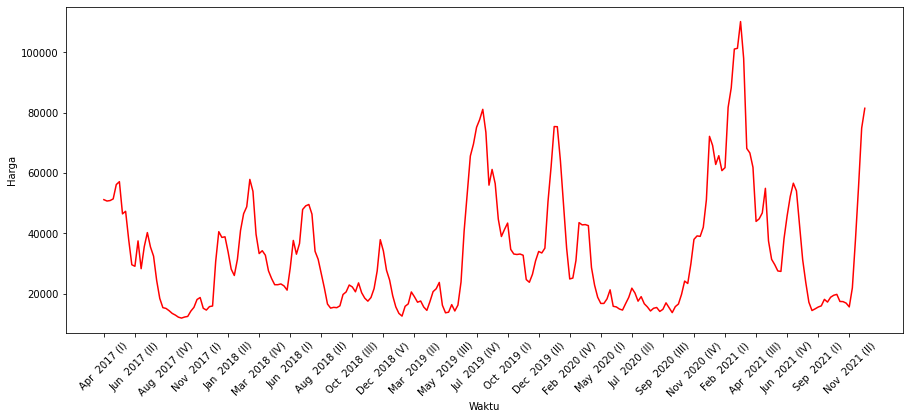

In [160]:
plt.figure(figsize=(15,6))
plt.plot(df_copy['Komoditas (Rp)'], df_copy['Jawa Timur'], color='red')
plt.xlabel('Waktu')
plt.ylabel('Harga')
plt.xticks(rotation=45)
plt.xticks(np.arange(0,len(df_copy.index)-1,10))
plt.show()

In [161]:
sd = statistics.pstdev(df_copy['Jawa Timur'].to_numpy())
meanS = statistics.mean(df_copy['Jawa Timur'].to_numpy())
print("Koefisien Variasi = ",sd/meanS*100,"%")

Koefisien Variasi =  58.83933157449134 %


In [162]:
Dt = df_copy['Jawa Timur']
Dmin = Dt.min()
Dmax = Dt.max()
N = Dt.count()
Z1 = 950
Z2 = 400

print(Dmin, Dmax, N)

11950 110100 246


In [163]:
R = Dmax+Z2 - (Dmin-Z1)
print(R)

99500


In [164]:
dif = []
df2 = df_copy

for i in range (N-1):
    dt = df['Jawa Timur'][i]
    dt2 = df['Jawa Timur'][i+1]
    ab = round(abs(dt2-dt),2)
    df2.at[i, '|Dt+1 - Dt|'] = ab

df2.at[N-1, '|Dt+1 - Dt|'] = 0

In [165]:
df2

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|
0,Apr 2017 (I),58495,51150,450.0
1,Apr 2017 (II),59712,50700,150.0
2,Apr 2017 (III),51705,50850,550.0
3,Apr 2017 (IV),53092,51400,4750.0
4,May 2017 (V),53954,56150,950.0
...,...,...,...,...
241,Nov 2021 (III),42489,21950,15950.0
242,Nov 2021 (IV),52289,37900,17650.0
243,Dec 2021 (I),71852,55550,19300.0
244,Dec 2021 (II),81729,74850,6550.0


In [166]:
mean = (sum(df2['|Dt+1 - Dt|']))/(N-1)
print(mean)

4498.163265306122


In [167]:
K = mean/2
if(K<1):
    K = round(K,1)
else:
    K = math.ceil(K)

print(K)

2250


In [168]:
n = math.ceil(R/K)
print(n)

45


In [169]:
himpFuzzy = pd.DataFrame()
ui = []
batasBawah = []
batasAtas = []
Ai = []
ui.append('u1')
Ai.append('A1')
batasBawah.append(Dmin-Z1)
batasAtas.append(batasBawah[0] + K)

for i in range(1, n):
    ui.append('u'+str(i+1))
    Ai.append('A'+str(i+1))
    batasBawah.append(batasAtas[i-1])
    batasAtas.append(batasBawah[i] + K)

himpFuzzy['ui'] = ui
himpFuzzy['Ai'] = Ai
himpFuzzy['batas bawah'] = batasBawah
himpFuzzy['batas atas'] = batasAtas

In [170]:
himpFuzzy['mi'] = (himpFuzzy['batas bawah'] + himpFuzzy['batas atas'])/2

In [171]:
himpFuzzy

,ui,Ai,batas bawah,batas atas,mi
0,u1,A1,11000,13250,12125.0
1,u2,A2,13250,15500,14375.0
2,u3,A3,15500,17750,16625.0
3,u4,A4,17750,20000,18875.0
4,u5,A5,20000,22250,21125.0
5,u6,A6,22250,24500,23375.0
6,u7,A7,24500,26750,25625.0
7,u8,A8,26750,29000,27875.0
8,u9,A9,29000,31250,30125.0
9,u10,A10,31250,33500,32375.0


In [172]:
# FLR dan FLRG
data = df2['Jawa Timur']

hasilFuzzy = []
for i in data:
    copyHimp = himpFuzzy
    cond1 = copyHimp['batas bawah'] <= i 
    cond2 = copyHimp['batas atas'] >= i 
    dfAi = copyHimp.where(cond1 & cond2) 
    dfAi = dfAi[~dfAi['ui'].isna()]
    fuzzyfikasi = dfAi['Ai'].iloc[0]
    hasilFuzzy.append(fuzzyfikasi)

df2['fuzzyfikasi'] = hasilFuzzy

In [173]:
df2

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi
0,Apr 2017 (I),58495,51150,450.0,A18
1,Apr 2017 (II),59712,50700,150.0,A18
2,Apr 2017 (III),51705,50850,550.0,A18
3,Apr 2017 (IV),53092,51400,4750.0,A18
4,May 2017 (V),53954,56150,950.0,A21
...,...,...,...,...,...
241,Nov 2021 (III),42489,21950,15950.0,A5
242,Nov 2021 (IV),52289,37900,17650.0,A12
243,Dec 2021 (I),71852,55550,19300.0,A20
244,Dec 2021 (II),81729,74850,6550.0,A29


In [174]:
nextState = []
for k in range(0, len(df2.index)-1):
    neSt = df2['fuzzyfikasi'].iloc[k+1]
    nextState.append(neSt)

df2['next state'] = pd.Series(nextState)

In [175]:
df2

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi,next state
0,Apr 2017 (I),58495,51150,450.0,A18,A18
1,Apr 2017 (II),59712,50700,150.0,A18,A18
2,Apr 2017 (III),51705,50850,550.0,A18,A18
3,Apr 2017 (IV),53092,51400,4750.0,A18,A21
4,May 2017 (V),53954,56150,950.0,A21,A21
...,...,...,...,...,...,...
241,Nov 2021 (III),42489,21950,15950.0,A5,A12
242,Nov 2021 (IV),52289,37900,17650.0,A12,A20
243,Dec 2021 (I),71852,55550,19300.0,A20,A29
244,Dec 2021 (II),81729,74850,6550.0,A29,A32


In [176]:
# FLRG
dfFLRG = pd.DataFrame()
dfFLRG['Ai'] = himpFuzzy['Ai']
dfFLRG['FLRG'] = ''

# ambil df2 kecuali baris terakhir karena next statenya kosong
df3 = df2[:-1]

for f in range(len(dfFLRG.index)):
    searchAi = 'A'+str(f+1)
    
    new = df3[df3['fuzzyfikasi'].isin([searchAi])]
    group = new['next state']
    group = group.to_numpy()
    
    if len(group) > 0 :
        dfFLRG['FLRG'][f] = group

In [177]:
dfFLRG

,Ai,FLRG
0,A1,"[A1, A1, A1, A1, A2, A3]"
1,A2,"[A2, A2, A2, A1, A2, A4, A2, A3, A2, A2, A3, A..."
2,A3,"[A3, A9, A2, A4, A4, A2, A3, A5, A3, A3, A2, A..."
3,A4,"[A2, A4, A2, A5, A3, A5, A3, A3, A3, A5, A5, A..."
4,A5,"[A8, A3, A6, A5, A6, A4, A8, A4, A5, A6, A3, A..."
5,A6,"[A4, A6, A6, A6, A5, A5, A5, A3, A14, A7, A4, ..."
6,A7,"[A10, A6, A5, A4, A6, A9, A7, A9]"
7,A8,"[A11, A7, A7, A12, A12, A7, A6, A8, A13]"
8,A9,"[A9, A12, A14, A11, A15, A12, A8]"
9,A10,"[A6, A14, A11, A8, A12, A7, A10, A10, A10, A7,..."


In [178]:
# hasil fuzzyfikasi
dfFLRG['defuzzyfikasi'] = ''

for g in range(len(dfFLRG.index)):
    ai = dfFLRG['Ai'].loc[g]
    flrg = dfFLRG['FLRG'].loc[g]
    hasil = 0

    if (len(flrg) == 0):
        fuzzyfikasi = himpFuzzy[himpFuzzy['Ai'] == ai]['mi']
        hasil = fuzzyfikasi.values[0]
    
    elif (len(flrg) == 1):
        fuzzyfikasi = himpFuzzy[himpFuzzy['Ai'] == flrg[0]]['mi']
        hasil = fuzzyfikasi.values[0]
        
    else:
        lenFlrg = len(flrg)
        for h in range(len(flrg)):
            mi = himpFuzzy[himpFuzzy['Ai'] == flrg[h]]['mi']
            bobot = (1/len(flrg)) * mi.values[0]
            hasil = hasil + bobot
            

    dfFLRG['defuzzyfikasi'][g] = hasil

In [179]:
dfFLRG

,Ai,FLRG,defuzzyfikasi
0,A1,"[A1, A1, A1, A1, A2, A3]",13250.0
1,A2,"[A2, A2, A2, A1, A2, A4, A2, A3, A2, A2, A3, A...",15125.0
2,A3,"[A3, A9, A2, A4, A4, A2, A3, A5, A3, A3, A2, A...",17551.470588
3,A4,"[A2, A4, A2, A5, A3, A5, A3, A3, A3, A5, A5, A...",18213.235294
4,A5,"[A8, A3, A6, A5, A6, A4, A8, A4, A5, A6, A3, A...",22410.714286
5,A6,"[A4, A6, A6, A6, A5, A5, A5, A3, A14, A7, A4, ...",23214.285714
6,A7,"[A10, A6, A5, A4, A6, A9, A7, A9]",25625.0
7,A8,"[A11, A7, A7, A12, A12, A7, A6, A8, A13]",30625.0
8,A9,"[A9, A12, A14, A11, A15, A12, A8]",35910.714286
9,A10,"[A6, A14, A11, A8, A12, A7, A10, A10, A10, A7,...",30817.307692


In [180]:
df2['yt'] = ''

for y in range (len(dfFLRG.index)):
    ai = dfFLRG['Ai'].loc[y]
    listAi = df2[df2['fuzzyfikasi'] == ai]
    yt = dfFLRG['defuzzyfikasi'][y]
    
    if len(listAi) > 0:
        idx = listAi.index
        for z in idx:
            df2.at[z+1,'yt'] = yt

In [181]:
df2

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi,next state,yt
0,Apr 2017 (I),58495.0,51150.0,450.0,A18,A18,
1,Apr 2017 (II),59712.0,50700.0,150.0,A18,A18,52906.25
2,Apr 2017 (III),51705.0,50850.0,550.0,A18,A18,52906.25
3,Apr 2017 (IV),53092.0,51400.0,4750.0,A18,A21,52906.25
4,May 2017 (V),53954.0,56150.0,950.0,A21,A21,52906.25
...,...,...,...,...,...,...,...
242,Nov 2021 (IV),52289.0,37900.0,17650.0,A12,A20,22410.714286
243,Dec 2021 (I),71852.0,55550.0,19300.0,A20,A29,37437.5
244,Dec 2021 (II),81729.0,74850.0,6550.0,A29,A32,51275.0
245,Dec 2021 (III),91293.0,81400.0,0.0,A32,NaN,74562.5


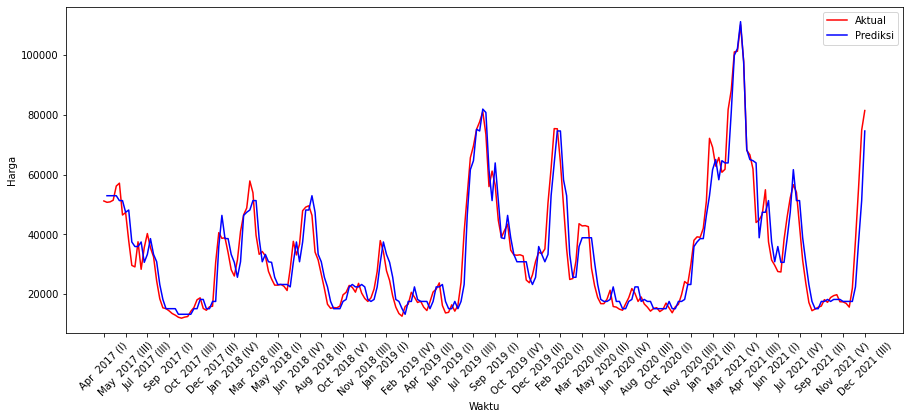

In [182]:
df2_copy = df2.copy()
df2_copy = df2_copy.drop(index=df2_copy.index[-1])
df2_copy.reset_index(inplace=True, drop=True)
df2_copy
plt.figure(figsize=(15,6))
plt.plot(df2_copy['Komoditas (Rp)'], df2_copy['Jawa Timur'], color='red', label='Aktual')
plt.plot(df2_copy['Komoditas (Rp)'][1:], df2_copy['yt'][1:], color='blue', label='Prediksi')
plt.xlabel('Waktu')
plt.ylabel('Harga')
plt.xticks(rotation=45)
plt.xticks(np.arange(0,len(df2_copy.index),7))
plt.legend()
plt.show()

In [183]:
# MAPE
y_actual = df2['Jawa Timur'][1:-1].to_numpy()
y_predict = df2['yt'][1:-1].to_numpy()

# MAE
MAE = mean_absolute_error(y_actual, y_predict)
print("MAE = ",MAE)

# Root MSE squared=False
RMSE = mean_squared_error(y_actual, y_predict, squared=False)
print("RMSE = ",RMSE)

MAPE = mean_absolute_percentage_error(y_actual, y_predict)
print("MAPE = ",MAPE*100)

MAE =  4073.561666424812
RMSE =  5768.129309510801
MAPE =  12.921970812268757


In [184]:
lastIndex = len(df2.index)
dfPredictNext = df2

for n in range (nPred-1):
    # Add fuzzyfikai dr hasil predict
    nilaiYt = dfPredictNext['yt'][lastIndex-1+n]
    
    copyHimp = himpFuzzy
    cond1 = copyHimp['batas bawah'] <= nilaiYt
    cond2 = copyHimp['batas atas'] >= nilaiYt
    dfAi = copyHimp.where(cond1 & cond2) 
    dfAi = dfAi[~dfAi['ui'].isna()]
    fuzzyfikasi = dfAi['Ai'].iloc[0]
    dfPredictNext.at[lastIndex + n-1, 'fuzzyfikasi'] = fuzzyfikasi

    # add predict
    yt = dfFLRG['defuzzyfikasi'][dfFLRG['Ai'] == fuzzyfikasi]
    dfPredictNext.at[lastIndex+n, 'yt'] = yt.values[0]    

In [185]:
dfPredictNext

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi,next state,yt
0,Apr 2017 (I),58495.0,51150.0,450.0,A18,A18,
1,Apr 2017 (II),59712.0,50700.0,150.0,A18,A18,52906.25
2,Apr 2017 (III),51705.0,50850.0,550.0,A18,A18,52906.25
3,Apr 2017 (IV),53092.0,51400.0,4750.0,A18,A21,52906.25
4,May 2017 (V),53954.0,56150.0,950.0,A21,A21,52906.25
...,...,...,...,...,...,...,...
302,NaN,NaN,NaN,NaN,A31,NaN,79625.0
303,NaN,NaN,NaN,NaN,A31,NaN,79625.0
304,NaN,NaN,NaN,NaN,A31,NaN,79625.0
305,NaN,NaN,NaN,NaN,A31,NaN,79625.0


In [191]:
dfPredictNext[len(dfPredictNext.index)-nPred:]

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi,next state,yt
246,Periode+1,NaN,NaN,NaN,A31,NaN,80750.0
247,NaN,NaN,NaN,NaN,A31,NaN,79625.0
248,NaN,NaN,NaN,NaN,A31,NaN,79625.0
249,NaN,NaN,NaN,NaN,A31,NaN,79625.0
250,NaN,NaN,NaN,NaN,A31,NaN,79625.0
...,...,...,...,...,...,...,...
302,NaN,NaN,NaN,NaN,A31,NaN,79625.0
303,NaN,NaN,NaN,NaN,A31,NaN,79625.0
304,NaN,NaN,NaN,NaN,A31,NaN,79625.0
305,NaN,NaN,NaN,NaN,A31,NaN,79625.0


In [186]:
df_result = df.copy()
df_result['yt'] = df2['yt']
df_result

,Komoditas (Rp),Semua Provinsi,Jawa Timur,yt
0,Apr 2017 (I),58495,51150,
1,Apr 2017 (II),59712,50700,52906.25
2,Apr 2017 (III),51705,50850,52906.25
3,Apr 2017 (IV),53092,51400,52906.25
4,May 2017 (V),53954,56150,52906.25
...,...,...,...,...
302,Jan 2023 (IV),50138,45850,79625.0
303,Feb 2023 (I),52962,54150,79625.0
304,Feb 2023 (II),54819,58300,79625.0
305,Feb 2023 (III),58716,59000,79625.0


In [187]:
df_result[len(df_result.index)-nPred:]

,Komoditas (Rp),Semua Provinsi,Jawa Timur,yt
246,Dec 2021 (IV),94115,73650,80750.0
247,Jan 2022 (I),80166,50900,79625.0
248,Jan 2022 (II),64353,36000,79625.0
249,Jan 2022 (III),58416,31950,79625.0
250,Jan 2022 (IV),50797,23050,79625.0
...,...,...,...,...
302,Jan 2023 (IV),50138,45850,79625.0
303,Feb 2023 (I),52962,54150,79625.0
304,Feb 2023 (II),54819,58300,79625.0
305,Feb 2023 (III),58716,59000,79625.0


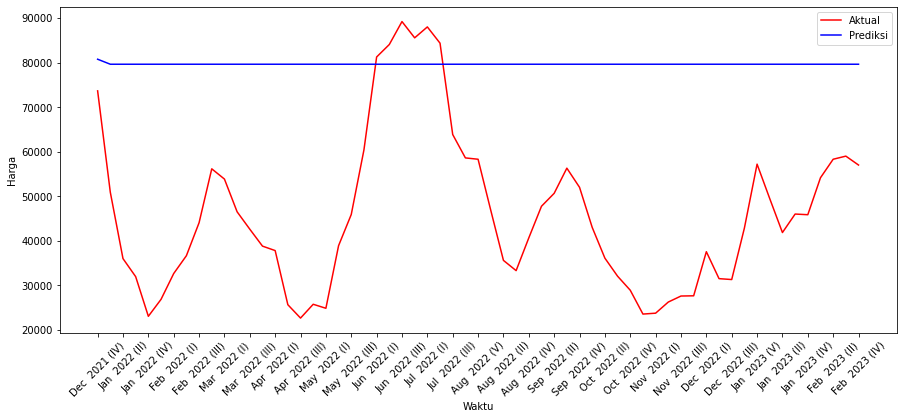

In [188]:
plt.figure(figsize=(15,6))
plt.plot(df_result['Komoditas (Rp)'][len(df_result.index)-nPred:], df_result['Jawa Timur'][len(df_result.index)-nPred:], color='red', label='Aktual')
plt.plot(df_result['Komoditas (Rp)'][len(df_result.index)-nPred:], df_result['yt'][len(df_result.index)-nPred:], color='blue', label='Prediksi')
plt.xlabel('Waktu')
plt.ylabel('Harga')
plt.xticks(rotation=45)
plt.xticks(np.arange(0,nPred,2))
plt.legend()
plt.show()

In [189]:
# MAPE pred
y_actualpred = df_result['Jawa Timur'][last-nPred:len(df_result.index)].to_numpy()
y_predictpred = df_result['yt'][last-nPred:len(df_result.index)].to_numpy()

# MAPE
MAPE2 = mean_absolute_percentage_error(y_actualpred, y_predictpred)
# Root MSE squared=False
RMSE2 = mean_squared_error(y_actualpred, y_predictpred, squared=False)
# MAE
MAE2 = mean_absolute_error(y_actualpred, y_predictpred)

print("Hasil MAPE untuk memprediksi data",nPred,"periode kedepan")
print("MAE = ",MAE2)
print("RMSE = ",RMSE2)
print("MAPE = ",MAPE2*100)

Hasil MAPE untuk memprediksi data 61 periode kedepan
MAE =  34670.49180327869
RMSE =  37859.44616518348
MAPE =  99.23698097109869


In [190]:
# MAPE all
y_actual2 = df_result['Jawa Timur'][1:len(df_result.index)].to_numpy()
# print(y_actual2)
y_predict2 = df_result['yt'][1:len(df_result.index)].to_numpy()
# MAPE
MAPE3 = mean_absolute_percentage_error(y_actual2, y_predict2)
# Root MSE squared=False
RMSE3 = mean_squared_error(y_actual2, y_predict2, squared=False)
# MAE
MAE3 = mean_absolute_error(y_actual2, y_predict2)
print("MAE = ",MAE3)
print("RMSE = ",RMSE3)
print("MAPE = ",MAPE3*100)

MAE =  10172.949700242089
RMSE =  17673.97831070577
MAPE =  30.12855780471525
